STEP 1: Main DataFrame (all data combined)
   Dataset          Model    Attack  RS-Score
0     COCO       Detr-R50    FGSM-i  0.778571
1     COCO       Detr-R50   FGSM-ii  0.697619
2     COCO       Detr-R50  FGSM-iii  0.447619
3     COCO       Detr-R50     PGD-i  0.226190
4     COCO       Detr-R50    PGD-ii  0.166667
..     ...            ...       ...       ...
75   KITTI  Detr-R101-DC5     C&W-i  0.139583
76   KITTI  Detr-R101-DC5    C&W-ii  0.102083
77   KITTI  Detr-R101-DC5   C&W-iii  0.083333
78   KITTI  Detr-R101-DC5      Ours  0.135417
79   KITTI  Detr-R101-DC5      APGD  0.325000

[80 rows x 4 columns]

DataFrame shape: (80, 4)

STEP 2: Creating 8 separate DataFrames (one for each model)

COCO-Detr-R50:
          RS-Score
Attack            
FGSM-i    0.778571
FGSM-ii   0.697619
FGSM-iii  0.447619
PGD-i     0.226190
PGD-ii    0.166667
C&W-i     0.321429
C&W-ii    0.250000
C&W-iii   0.207143
Ours      0.200000
APGD      0.266667

COCO-Detr-R50-DC5:
          RS-Score
Attack      

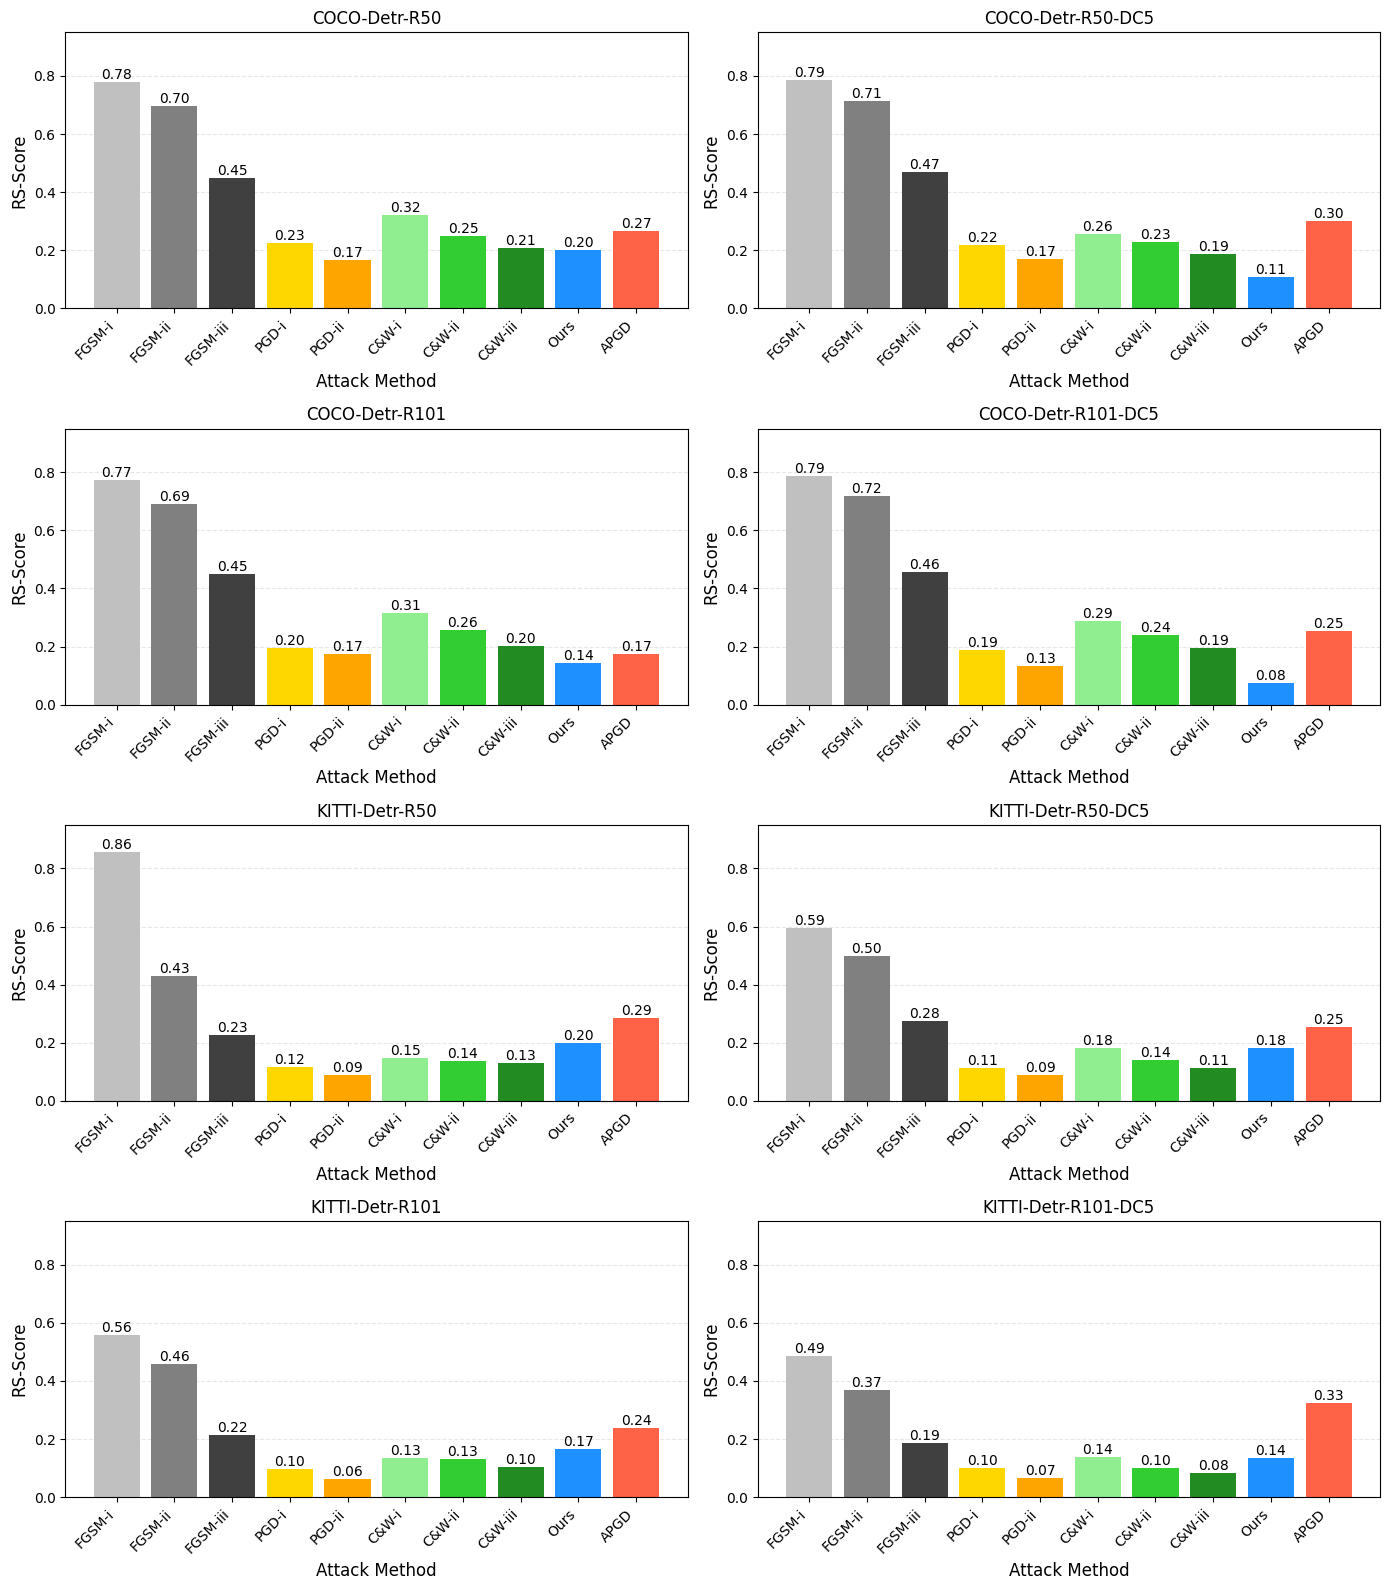


STEP 4: Summary Statistics

Average RS-Score by Attack Method:
Attack
FGSM-i      0.702497
FGSM-ii     0.571801
FGSM-iii    0.340631
APGD        0.262103
C&W-i       0.223301
C&W-ii      0.185858
PGD-i       0.157016
C&W-iii     0.152551
Ours        0.151370
PGD-ii      0.118771
Name: RS-Score, dtype: float64

Average RS-Score by Dataset:
Dataset
COCO     0.342733
KITTI    0.230446
Name: RS-Score, dtype: float64

Average RS-Score by Model:
Model
Detr-R50         0.309048
Detr-R50-DC5     0.294099
Detr-R101        0.276814
Detr-R101-DC5    0.266398
Name: RS-Score, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


RS_results = {
  "COCO": {
    "Detr-R50": {
      "RS-score": {
        "FGSM-i": 0.7785714,
        "FGSM-ii": 0.697619,
        "FGSM-iii": 0.447619,
        "PGD-i": 0.2261905,
        "PGD-ii": 0.1666667,
        "C&W-i": 0.3214286,
        "C&W-ii": 0.25,
        "C&W-iii": 0.2071429,
        "Ours": 0.2,
        "APGD": 0.2666667
      }
    },
    "Detr-R50-DC5": {
      "RS-score": {
        "FGSM-i": 0.7875289,
        "FGSM-ii": 0.7136259,
        "FGSM-iii": 0.4688222,
        "PGD-i": 0.2170907,
        "PGD-ii": 0.1685912,
        "C&W-i": 0.256351,
        "C&W-ii": 0.2286374,
        "C&W-iii": 0.18706,
        "Ours": 0.108545,
        "APGD": 0.3025404
      }
    },
    "Detr-R101": {
      "RS-score": {
        "FGSM-i": 0.7724138,
        "FGSM-ii": 0.6896552,
        "FGSM-iii": 0.4482759,
        "PGD-i": 0.1954023,
        "PGD-ii": 0.173931,
        "C&W-i": 0.3149425,
        "C&W-ii": 0.2574713,
        "C&W-iii": 0.2022989,
        "Ours": 0.1448276,
        "APGD": 0.173103
      }
    },
    "Detr-R101-DC5": {
      "RS-score": {
        "FGSM-i": 0.7884187,
        "FGSM-ii": 0.7171492,
        "FGSM-iii": 0.4565702,
        "PGD-i": 0.1893096,
        "PGD-ii": 0.1336303,
        "C&W-i": 0.2895323,
        "C&W-ii": 0.2383073,
        "C&W-iii": 0.1937639,
        "Ours": 0.0757238,
        "APGD": 0.2538976
      }
    }
  },
  "KITTI": {
    "Detr-R50": {
      "RS-score": {
        "FGSM-i": 0.8571429,
        "FGSM-ii": 0.4285714,
        "FGSM-iii": 0.2275132,
        "PGD-i": 0.1164021,
        "PGD-ii": 0.0899471,
        "C&W-i": 0.1481481,
        "C&W-ii": 0.1375661,
        "C&W-iii": 0.1296296,
        "Ours": 0.1984127,
        "APGD": 0.2857143
      }
    },
    "Detr-R50-DC5": {
      "RS-score": {
        "FGSM-i": 0.59375,
        "FGSM-ii": 0.5,
        "FGSM-iii": 0.2755682,
        "PGD-i": 0.1136364,
        "PGD-ii": 0.0880682,
        "C&W-i": 0.1818182,
        "C&W-ii": 0.1420455,
        "C&W-iii": 0.1136364,
        "Ours": 0.1818182,
        "APGD": 0.2528409
      }
    },
    "Detr-R101": {
      "RS-score": {
        "FGSM-i": 0.5567302,
        "FGSM-ii": 0.4590409,
        "FGSM-iii": 0.2152593,
        "PGD-i": 0.0980926,
        "PGD-ii": 0.0626703,
        "C&W-i": 0.1346005,
        "C&W-ii": 0.1307502,
        "C&W-iii": 0.1035422,
        "Ours": 0.1662125,
        "APGD": 0.2370572
      }
    },
    "Detr-R101-DC5": {
      "RS-score": {
        "FGSM-i": 0.4854167,
        "FGSM-ii": 0.36875,
        "FGSM-iii": 0.1854167,
        "PGD-i": 0.1,
        "PGD-ii": 0.0666667,
        "C&W-i": 0.1395833,
        "C&W-ii": 0.1020833,
        "C&W-iii": 0.0833333,
        "Ours": 0.1354167,
        "APGD": 0.325
      }
    }
  }
}


# STEP 1: Create a flattened dataframe from nested dictionary
def create_dataframe_from_results(results_dict):
    """
    Converts nested RS_results dictionary into a pandas DataFrame.
    Structure: Dataset -> Model -> RS-score -> Attack -> Value
    """
    data = []
    
    for dataset, models in results_dict.items():
        for model, metrics in models.items():
            rs_scores = metrics['RS-score']
            for attack, score in rs_scores.items():
                data.append({
                    'Dataset': dataset,
                    'Model': model,
                    'Attack': attack,
                    'RS-Score': score
                })
    
    df = pd.DataFrame(data)
    return df

# Create the main dataframe
df_main = create_dataframe_from_results(RS_results)

print("=" * 80)
print("STEP 1: Main DataFrame (all data combined)")
print("=" * 80)
print(df_main)
print(f"\nDataFrame shape: {df_main.shape}")

# STEP 2: Create separate dataframes for each dataset-model combination
print("\n" + "=" * 80)
print("STEP 2: Creating 8 separate DataFrames (one for each model)")
print("=" * 80)

dataframes_dict = {}
for dataset in RS_results.keys():
    for model in RS_results[dataset].keys():
        key = f"{dataset}-{model}"
        df_subset = df_main[(df_main['Dataset'] == dataset) & (df_main['Model'] == model)].copy()
        df_subset = df_subset.drop(['Dataset', 'Model'], axis=1)
        df_subset = df_subset.set_index('Attack')
        dataframes_dict[key] = df_subset
        print(f"\n{key}:")
        print(df_subset)

# STEP 3: Create 8 barplots (one for each model)
print("\n" + "=" * 80)
print("STEP 3: Creating 8 barplots")
print("=" * 80)

# Define colors for each attack method
colors_map = {
    'FGSM-i': '#C0C0C0',      # Gray
    'FGSM-ii': '#808080',      # Dark gray
    'FGSM-iii': '#404040',     # Darker gray
    'PGD-i': '#FFD700',        # Gold/Yellow
    'PGD-ii': '#FFA500',       # Orange
    'C&W-i': '#90EE90',        # Light green
    'C&W-ii': '#32CD32',       # Lime green
    'C&W-iii': '#228B22',      # Forest green
    'Ours': '#1E90FF',         # Dodger blue
    'APGD': '#FF6347'          # Tomato/Red
}

# Create a figure with 4 rows and 2 columns (8 subplots total)
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()  # Flatten to 1D for easier iteration

# Iterate through each model and create a barplot
for idx, (key, df_subset) in enumerate(dataframes_dict.items()):
    ax = axes[idx]
    
    # Prepare data
    attacks = df_subset.index
    values = df_subset['RS-Score'].values
    colors = [colors_map.get(attack, '#808080') for attack in attacks]
    
    # Create barplot
    bars = ax.bar(attacks, values, color=colors, linewidth=1.2)
    
    # Customize the plot
    ax.set_ylabel('RS-Score', fontsize=12)
    ax.set_xlabel('Attack Method', fontsize=12)
    ax.set_title(key, fontsize=12)
    ax.set_ylim(0, 0.95)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)
    
    # Add value labels on top of bars (optional)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

# Adjust layout to prevent overlapping labels
plt.tight_layout()

# Save the figure
output_path = 'rs_scores_barplots.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nBarplots saved to: {output_path}")

plt.show()

# STEP 4: Summary statistics
print("\n" + "=" * 80)
print("STEP 4: Summary Statistics")
print("=" * 80)

print("\nAverage RS-Score by Attack Method:")
print(df_main.groupby('Attack')['RS-Score'].mean().sort_values(ascending=False))

print("\nAverage RS-Score by Dataset:")
print(df_main.groupby('Dataset')['RS-Score'].mean())

print("\nAverage RS-Score by Model:")
print(df_main.groupby('Model')['RS-Score'].mean().sort_values(ascending=False))
